In [13]:
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
                            StratifiedKFold,
                            cross_validate
)
from sklearn.metrics import(
    confusion_matrix
)
warnings.filterwarnings('ignore')



Load the data

In [3]:
X_train = np.load('../artifacts/x_train.npz')['arr_0']
Y_train = np.load('../artifacts/y_train.npz')['arr_0']
X_test = np.load('../artifacts/x_test.npz')['arr_0']
Y_test = np.load('../artifacts/y_test.npz')['arr_0']

Define Multimodels

In [4]:
models = {
    'LogisticRegression':LogisticRegression(),
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier()
    }

Configure K fold cv


In [5]:
from random import shuffle


cv = StratifiedKFold(
    n_splits = 6,
    random_state= 42,
    shuffle= True 
)

Run the corss valiation for each of this model

In [11]:

trained_models = {}

for model_name,model in models.items():
    print(f"\ncross validation on {model_name} ")

    cv_reslts = cross_validate(
           model,
           X_train,Y_train,
           cv= cv, scoring='f1',
           return_estimator=True,
           return_train_score=False
    )
    test_score = cv_reslts['test_score']
    best_split_index = np.argmax(test_score)
    estimator = cv_reslts['estimator'][best_split_index]
    trained_models[model_name]=estimator


cross validation on LogisticRegression 

cross validation on Decision Tree 

cross validation on Random Forest 


In [12]:
trained_models

{'LogisticRegression': LogisticRegression(),
 'Decision Tree': DecisionTreeClassifier(),
 'Random Forest': RandomForestClassifier()}

In [16]:



Y_hat_tests = {}
for model_name,model in trained_models.items():
    Y_hat_test = model.predict(X_test)
    Y_hat_tests[model_name]=Y_hat_test
Y_hat_tests


{'LogisticRegression': array([1, 0, 1, ..., 1, 0, 0], shape=(2000,)),
 'Decision Tree': array([0, 0, 0, ..., 1, 0, 0], shape=(2000,)),
 'Random Forest': array([0, 0, 0, ..., 1, 0, 1], shape=(2000,))}

In [19]:
cm1 = confusion_matrix(Y_test,Y_hat_tests['LogisticRegression'])
cm2 = confusion_matrix(Y_test,Y_hat_tests['Decision Tree'])
cm3 = confusion_matrix(Y_test,Y_hat_tests['Random Forest'])

Text(1314.8398692810458, 0.5, 'Actual')

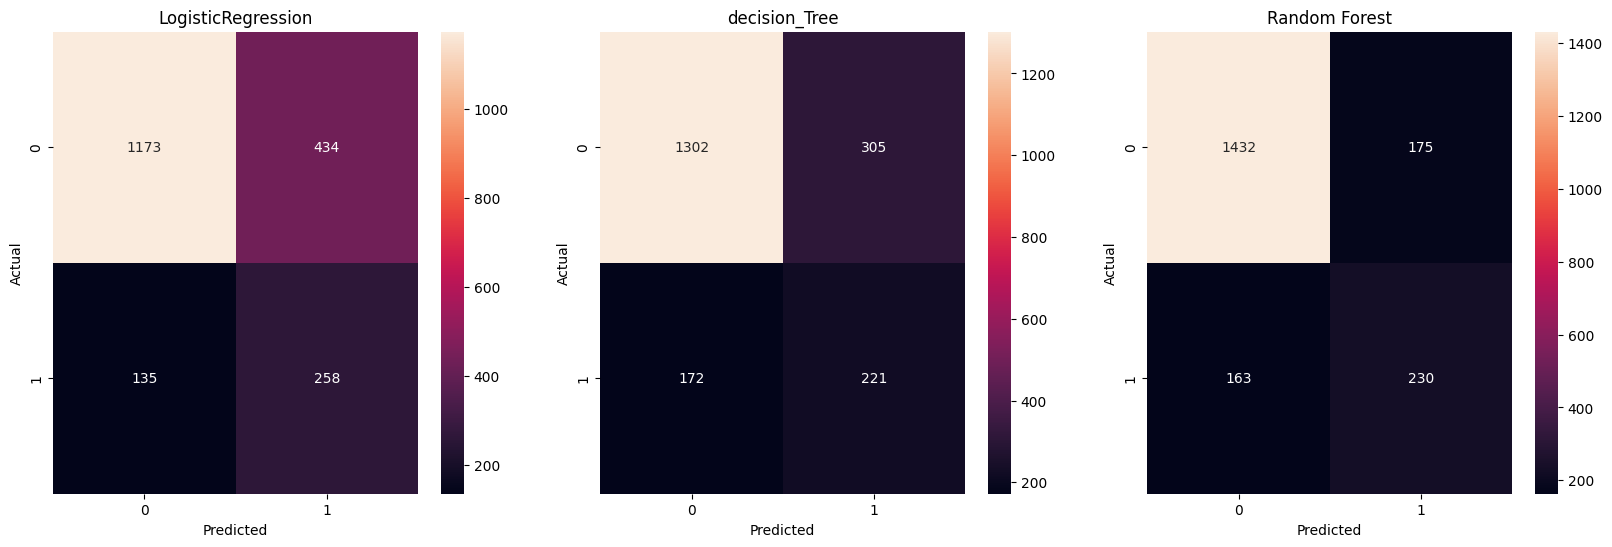

In [25]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3, figsize = (20,6))

sns.heatmap(cm1,annot=True,fmt='d',ax=ax1)
ax1.set_title('LogisticRegression')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')


sns.heatmap(cm2,annot=True,fmt='d',ax=ax2)
ax2.set_title('decision_Tree')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')


sns.heatmap(cm3,annot=True,fmt='d',ax=ax3)
ax3.set_title('Random Forest')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
